## image eda
inspect downloaded photos: counts, dims, dupes, split. runs on whatever's on disk

In [1]:
import hashlib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

IMAGE_DIR = Path("../data/raw/images")

In [2]:
# walk folders, open each image once, flag corrupt
records, corrupt = [], []
for folder in tqdm(sorted(IMAGE_DIR.iterdir())):
    if not folder.is_dir():
        continue
    key = folder.name.split("_")[0]
    species = " ".join(folder.name.split("_")[1:])
    for p in folder.glob("*.jpg"):
        try:
            with Image.open(p) as im:
                w,h = im.size
                mode = im.mode
            records.append({"path":p.as_posix(),"species_key":key,"species":species,"width":w,"height":h,"mode":mode,"bytes":p.stat().st_size})
        except Exception as e:
            corrupt.append((p.as_posix(),repr(e)))

img = pd.DataFrame(records)
print(len(img), "images,", img["species_key"].nunique(), "species,", len(corrupt), "corrupt")
img.head()

  0%|          | 0/4172 [00:00<?, ?it/s]

413873 images, 4144 species, 0 corrupt


,path,species_key,species,width,height,mode,bytes
0,../data/raw/images/10010617_Pentanema_britanni...,10010617,Pentanema britannicum,375,500,RGB,59623
1,../data/raw/images/10010617_Pentanema_britanni...,10010617,Pentanema britannicum,500,375,RGB,114846
2,../data/raw/images/10010617_Pentanema_britanni...,10010617,Pentanema britannicum,375,500,RGB,129258
3,../data/raw/images/10010617_Pentanema_britanni...,10010617,Pentanema britannicum,375,500,RGB,128212
4,../data/raw/images/10010617_Pentanema_britanni...,10010617,Pentanema britannicum,375,500,RGB,116987


count    4144.0
mean       99.9
std         0.6
min        77.0
25%       100.0
50%       100.0
75%       100.0
max       100.0
dtype: float64


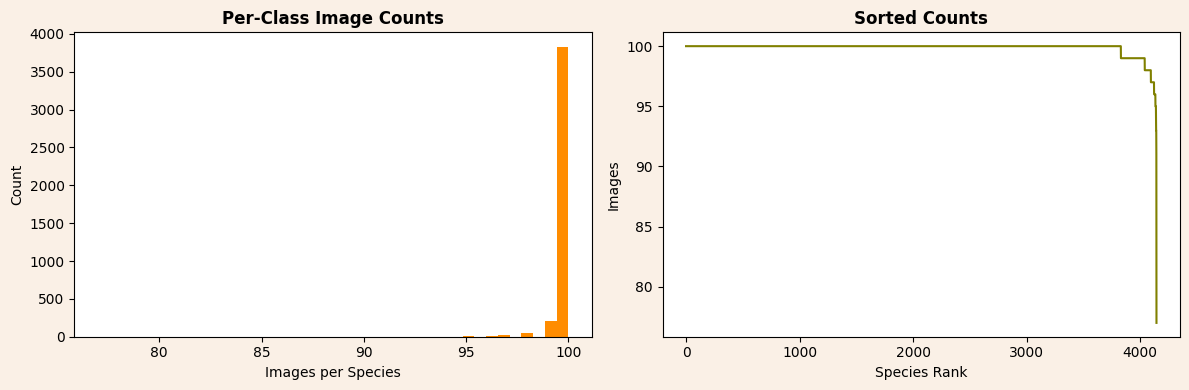


most under-filled:
species
Circaea alpina           77
Spathodea campanulata    91
Arisarum vulgare         93
Salvia azurea            93
Oenanthe javanica        94
Arctostaphylos glauca    95
Maianthemum stellatum    95
Daucus carota            95


In [3]:
# per-class counts (capped at 100/species in download)
counts = img.groupby("species").size().sort_values()
print(counts.describe().round(1))

fig,axs = plt.subplots(1,2,figsize=(12,4))
fig.set_facecolor("linen")

axs[0].hist(counts.values,bins=40,color="darkorange")
axs[0].set_xlabel("Images per Species")
axs[0].set_ylabel("Count")
axs[0].set_title("Per-Class Image Counts",weight="bold")

axs[1].plot(counts.sort_values(ascending=False).values,color="olive")
axs[1].set_xlabel("Species Rank")
axs[1].set_ylabel("Images")
axs[1].set_title("Sorted Counts",weight="bold")
plt.tight_layout()
plt.show()

print("\nmost under-filled:")
print(counts.head(8).to_string())

width  {'min': 84.0, '50%': 375.0, 'max': 500.0}
height {'min': 39.0, '50%': 500.0, 'max': 500.0}
modes  {'RGB': 413861, 'L': 11, 'CMYK': 1}


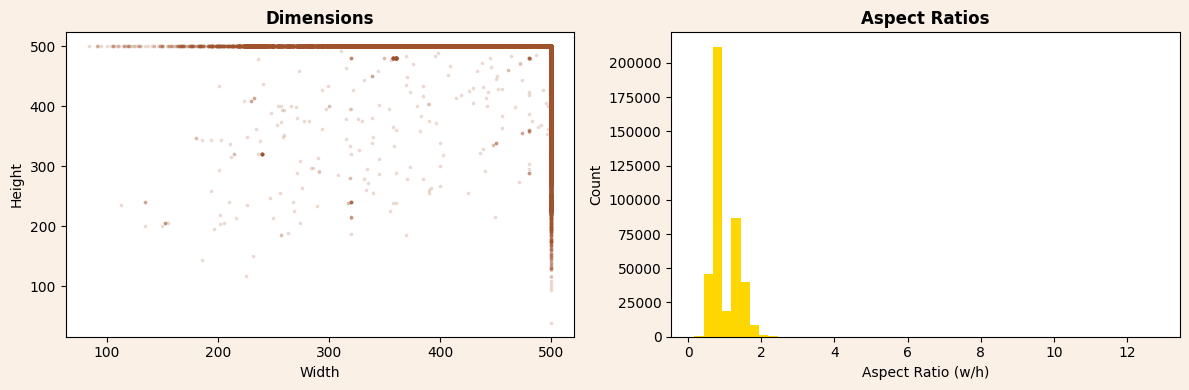

In [4]:
# dims + color mode (inat medium is ~500px long edge)
print("width ", img["width"].describe()[["min","50%","max"]].to_dict())
print("height", img["height"].describe()[["min","50%","max"]].to_dict())
print("modes ", img["mode"].value_counts().to_dict())

fig,axs = plt.subplots(1,2,figsize=(12,4))
fig.set_facecolor("linen")

axs[0].scatter(img["width"],img["height"],s=3,alpha=0.15,color="sienna")
axs[0].set_xlabel("Width")
axs[0].set_ylabel("Height")
axs[0].set_title("Dimensions",weight="bold")

axs[1].hist(img["width"]/img["height"],bins=50,color="gold")
axs[1].set_xlabel("Aspect Ratio (w/h)")
axs[1].set_ylabel("Count")
axs[1].set_title("Aspect Ratios",weight="bold")
plt.tight_layout()
plt.show()

In [5]:
# exact dupes via md5 (same photo across observations)
def md5(path):
    h = hashlib.md5()
    h.update(Path(path).read_bytes())
    return h.hexdigest()

img["md5"] = [md5(p) for p in tqdm(img["path"])]
dupe = img["md5"].duplicated(keep="first")
print(int(dupe.sum()), "exact dupes")

# cross-species dupes = label leakage, the concerning kind
cross = img.groupby("md5")["species"].nunique()
print(int((cross>1).sum()), "hashes in >1 species")

  0%|          | 0/413873 [00:00<?, ?it/s]

6058 exact dupes
5302 hashes in >1 species


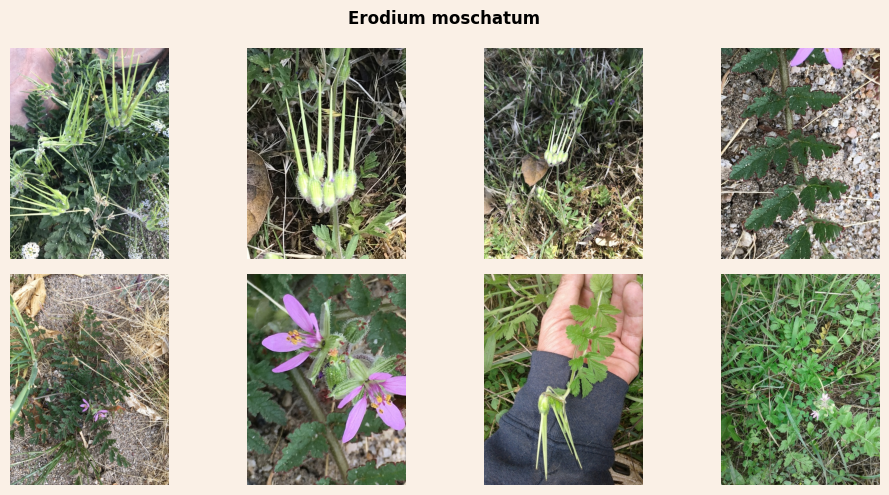

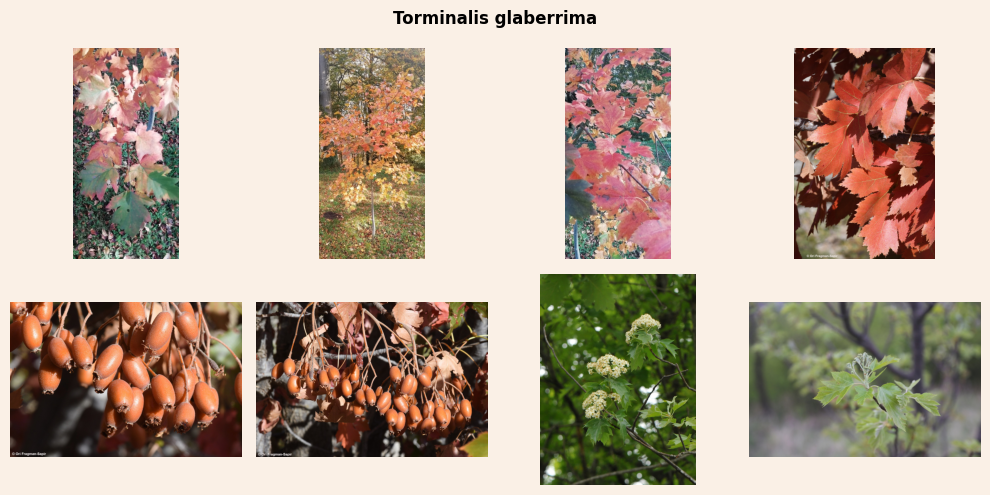

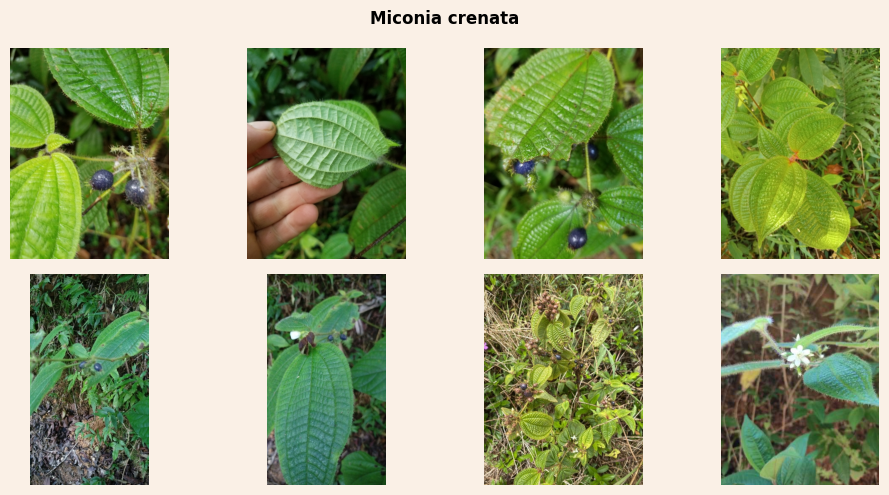

In [6]:
# eyeball a few species for label quality
def show_species(name, n=8):
    rows = img[img["species"]==name].head(n)
    fig,axs = plt.subplots(2,4,figsize=(10,5))
    fig.set_facecolor("linen")
    fig.suptitle(name,weight="bold")
    for ax,(_,row) in zip(axs.ravel(),rows.iterrows()):
        ax.imshow(Image.open(row["path"]))
        ax.axis("off")
    for ax in axs.ravel()[len(rows):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

for name in img["species"].value_counts().head(3).index:
    show_species(name)

In [7]:
# stratified 70/15/15 split within each species
from sklearn.model_selection import train_test_split

clean = img[~dupe].copy()
keep = clean.groupby("species").filter(lambda g: len(g)>=10)  # need enough to split
print(keep["species"].nunique(), "species kept,", clean["species"].nunique()-keep["species"].nunique(), "dropped")

parts = []
for name,g in keep.groupby("species"):
    tr,tmp = train_test_split(g,test_size=0.30,random_state=42)
    va,te = train_test_split(tmp,test_size=0.50,random_state=42)
    for part,split in [(tr,"train"),(va,"val"),(te,"test")]:
        part = part.copy()
        part["split"] = split
        parts.append(part)

splits = pd.concat(parts).reset_index(drop=True)
print(splits["split"].value_counts().to_string())
splits[["path","species_key","species","split"]].to_csv("../data/splits.csv",index=False)
print("wrote", len(splits), "rows")

4094 species kept, 22 dropped
split
train    285136
test      61335
val       61288
wrote 407759 rows
